# Practical 2 : Generative and Discriminative Models


In this practical, we will compare the Naïve Bayes Classifier (NBC) and Logistic Regression on several
datasets. As part of the practical you should read briefly the following paper:



**On Discriminative vs. Generative classifiers: A comparison of logistic regression
and naive Bayes**  
*Andrew Y. Ng and Michael I. Jordan*  
Advances in Neural Information Processing Systems (NIPS) 2001.

The paper is available on OLAT. 

You should read the Introduction and the Experiments sections. The goal of this practical is
to qualitatively reproduce some of the experimental results in this paper. You are strongly
encouraged to read the rest of the paper, which is rather short and straightforward to read,
though some of you may want to skip the formal proofs.

## Naïve Bayes Classifier (NBC)

You should implement a Naïve Bayes Classifier from scartch using NumPy. To keep your code tidy,
we recommend implementing it as a class. 
The classifier should be able to handle binary and continuous features. 
To earn the bonus points, the classifier should be able to handle categorical features as well. 
Suppose the data has 3
different features, the first being binary, the second being continuous and the third being categorical. Write an implementation that you can initialise as follows:

    nbc = NBC(feature_types=['b', 'r', 'c'])

Along the lines of classifiers provided in sklearn, you want to implement two more functions,
**fit** and **predict**. 
Recall the joint distribution of a generative model: $p(\mathbf{x}, y \mid \theta, \pi) = p(y \mid \pi) \cdot p(\mathbf{x} \mid y, \theta)$.
The **fit** function is to estimate all the parameters ($\theta$ and $\pi$) of the NBC, i.e., train the classifier. The **predict** function is to compute the probabilities that the new input belongs to all classes and
then return the class that has the largest probability, i.e., make the prediction.

    nbc.fit(X_train, y_train)
    ypredicted = nbc.predict(X_test)
    test_accuracy = np.mean(ypredicted == ytest)

Here we import the libraries. 

In [1]:
%matplotlib inline
import pylab
pylab.rcParams['figure.figsize'] = (10., 10.)

import pickle as cp
import matplotlib.pyplot as plt
import numpy as np

### Class-conditional distributions

Before implementing NBC, we first implement the class-conditional distributions $p(\mathbf{x} \mid y, \theta)$. Your implementation should have two functions: **estimate** and **get_log_probability**. 

- The **estimate** function takes data as input and models the data using some distribution $p(x \mid \theta)$, where $\theta$ is the parameters of this distribution. The function estimates the parameters $\theta$ using maximum likelihood estimators (MLE). 
For example, in the case of continuous features, we use the Gaussian distribution to model the data. The estimate function will find the parameters $\mu$ and $\sigma$ for the Gaussian distribution with respect to the input data. 

- The **get_log_probability** function takes as input a new data point $x_{new}$ and returns the log of $p(x_{new} \mid \theta)$. For the Gaussian distribution, the function get_probability will return $\mathcal{N}(x_{new} \mid \mu, \sigma)$. 

For different types of features, you need to use different distributions.
You can import statistic libraries (e.g., `scipy.stats`) for the implementation of the distributions. 

- For **continuous features**: Use Gaussian distribution
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
- For **binary features**: Use Bernoulli distribution 
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html
- For **categorical features**: Use Multinoulli distribution (The multinoulli distribution is a special case of the multinomial distribution, where the number of trials is 1)
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multinomial.html



**Implementation Issues:**
- The probabilities can be very small. To avoid underflow issues, you should compute the log of the probabilities. Read more: (Mur) Chapter 3.5.3 / Lecture Notes
- The standard deviation for Gaussian distributions should never be exactly 0, so in
case your calculated standard deviation is 0, you may want to set it to a small value such as 1e − 6. This is to ensure that your code never encounters division by zero or
taking logarithms of 0 errors. 
For this practical, please set the small value to 1e-6.
- Laplace/Additive smoothing: You want to ensure that the estimates for the parameter for the Bernoulli and Multinoulli random variables is never exactly 0 or 1. For this reason you should consider using Laplace smoothing (https://en.wikipedia.org/wiki/Additive_smoothing).
For this practical, please set alpha to 1.
- We will check the correctness of your implementation using the tests below.
- For simplicity, you can assume the data values for binary features are integers from {0,1} and the data for a categorical feature with M categories are integers from {0, ..., M-1}.
- Fell free to add auxiliary functions or change the parameters of the functions. If you change the parameters of the functions, make sure you change the tests accordingly, so we can test your code.


In [2]:
import scipy.stats as stats
ALPHA = 1.0 # for additive smoothing

# Distribution for continuous features
class ContFeatureParam:
    def estimate(self, X):
        # TODO: Estimate the parameters for the Gaussian distribution 
        # so that it best describes the input data X
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        
        self.mean = np.mean(X)
        self.std = np.std(X) 
        if self.std <= 1e-6:
            self.std = 1e-6


    def get_log_probability(self, X_new):
        # TODO: return the log of the density values for the input values X_new
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        return stats.norm.logpdf(X_new, self.mean, self.std)

# Distribution for binary features
class BinFeatureParam:
    def estimate(self, X):
        # TODO: Estimate the parameters for the Bernoulli distribution 
        # so that it best describes the input data X
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        self.theta = (np.sum(X) + ALPHA)/ (len(X) + 2*ALPHA)
        

    def get_log_probability(self, X_new):
        # TODO: return the log of the probability values for the input values X_new
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        log_prob = np.zeros_like(X_new, dtype=float)
        log_prob[X_new == 1] = np.log(self.theta)
        log_prob[X_new == 0] = np.log(1 - self.theta)
        return log_prob

# Distribution for categorical features
class CatFeatureParam:
    
    # we need to know the number of categories for the categorical feature
    def __init__(self, num_of_categories):
        self._num_of_categories = num_of_categories
    
    def estimate(self, X):
        # TODO: Estimate the parameters for the Multinoulli distribution 
        # so that it best describes the input data X
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        counts = np.zeros(self._num_of_categories)
        for value in X:
            counts[value] += 1
        self.theta = (counts + ALPHA) / (len(X) + self._num_of_categories * ALPHA)
        
    def get_log_probability(self, X_new):
        # TODO: return the log of the probability values for the input values X_new
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        log_theta = np.log(self.theta)
        log_min = -1e9  
        log_probs = np.full(X_new.shape, log_min)

        valid = (X_new >= 0) & (X_new < len(log_theta))
        log_probs[valid] = log_theta[X_new[valid]]

        return log_probs


**Tests:**
    
We will use the code below to test the correctness of your code.

In [3]:
# continuous features

X = np.array([2.70508547,2.10499698,1.76019132,3.42016431,3.47037973,3.67435061,1.84749286,4.3388506,2.27818252,4.65165335])

param = ContFeatureParam()
param.estimate(X)
probs = param.get_log_probability(np.array([0,1,2,3]))
print(probs)

[-5.64670664 -3.02757918 -1.44567455 -0.90099277]


In [4]:
# binary features

X = np.array([0,0,1,1,0,1,0,1,1,1])

param = BinFeatureParam()
param.estimate(X)
probs = param.get_log_probability(np.array([0,1]))
print(probs)

[-0.87546874 -0.5389965 ]


In [5]:
# categorical features (bonus task)

X = np.array([0,6,5,4,0,6,6,4,1,1,2,3,8,8,1,6,4,9,0,2,2,3,8,0,2])

param = CatFeatureParam(num_of_categories=10)
param.estimate(X)
probs = param.get_log_probability(np.array([0,1,2,3,4,5,6,7,8,9]))
print(probs)

[-1.94591015 -2.1690537  -1.94591015 -2.45673577 -2.1690537  -2.86220088
 -1.94591015 -3.55534806 -2.1690537  -2.86220088]


### Implement NBC

We are now ready to implement NBC. We follow the structure of models in scikit-learn. We implement NBC as a class with functions **init**, **fit** and **predict**.
The **init** function takes as input the types of features and initialise the classifier. The **fit** function takes the training data as input and estimates the parameters. The **predict** function predicts the label for the input data. 

**Implementation Issues:**
- You should use matrix operations rather than loops. In general, loops over classes or features are OK, but loops over the rows of data are not a good idea.
- The probabilities can be very small. To avoid underflow issues, you should do the calculations in log space. Read more: (Mur) Chapter 3.5.3 / Lecture Note
- For simplicity, you can assume the data values for binary features are integers from {0, 1} and the data for a categorical feature with M categories are integers from {0, ..., M-1}.
- Fell free to add auxiliary functions or change the parameters of the functions. If you change the parameters of the functions, make sure you change the tests accordingly, so we can test your code.

In [6]:
# Your task is to implement the three functions of NBC. 

import numpy as np



class NBC:
    # Inputs:
    #   feature_types: the array of the types of the features, e.g., feature_types=['b', 'r', 'c']
    def __init__(self, feature_types=[]):
        # TODO: 
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        self.feature_types = feature_types
        self.num_features = len(feature_types)
        self.class_feature_params = {}
        self.log_priors = None
        
    # The function uses the input data to estimate all the parameters of the NBC
    def fit(self, X, y):
        # TODO: 
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        classes = np.unique(y)
        self.log_priors = np.zeros(len(classes))
                
        for class_label in classes:
            class_label_count = np.sum(y == class_label)
            prior_prob = class_label_count / len(y)
            
            idx = np.where(classes == class_label)[0][0]
            self.log_priors[idx] = np.log(prior_prob)     
            
            X_class = X[y == class_label]
            self.class_feature_params[idx] = []
            
            for feature_idx in range(self.num_features):
                
                feature_type = self.feature_types[feature_idx]
                feature_values = X_class[:, feature_idx]
                
                if feature_type == 'r':
                    model = ContFeatureParam()
                elif feature_type == 'b':
                    model = BinFeatureParam()
                elif feature_type == 'c':
                    num_of_categories = int(np.max(X[:, feature_idx])) + 1
                    model = CatFeatureParam(num_of_categories)
        
                model.estimate(feature_values)
                self.class_feature_params[idx].append(model)
                
                
    # The function takes the data X as input, and predicts the class for the data
    def predict(self, X):
        # TODO: 
        # The code below is just for compilation. 
        # You need to replace it by your own code.
        num_samples = X.shape[0]
        num_classes = len(self.log_priors)
        log_posteriors = np.zeros((num_samples, num_classes))
        
        for class_idx in range(num_classes):
            log_posteriors[:, class_idx] += self.log_priors[class_idx]
            
            for feature_idx in range(self.num_features):
                
                model = self.class_feature_params[class_idx][feature_idx]
                feature_values = X[:, feature_idx]
                log_probs = model.get_log_probability(feature_values)
                log_posteriors[:, class_idx] += log_probs
                
        predictions = np.argmax(log_posteriors, axis=1)

        return predictions

**Tests**

We will use the code below to check your code.

In [7]:
# All features of the iris dataset are continuous.

from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris['data'], iris['target']

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc_iris = NBC(feature_types=['r', 'r', 'r', 'r'])
nbc_iris.fit(Xtrain, ytrain)
yhat = nbc_iris.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy) # should be larger than 90%
print(yhat)

Accuracy: 0.9333333333333333
[2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [8]:
# All features of this dataset are binary
import pandas as pd
data = pd.read_csv('./datasets/binary_test.csv', header=None)
data = data.to_numpy()

X = data[:,1:]
y = data[:,0]

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc = NBC(feature_types=['b'] * 16)
nbc.fit(Xtrain, ytrain)
yhat = nbc.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy) # should be larger than 85%
print(yhat)

Accuracy: 0.8723404255319149
[1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 0
 0 0 1 0 0 0 0 1 1 0]


In [9]:
# All features of this dataset are categorical (bonus task)

data = pd.read_csv('./datasets/categorical_test.csv', header=None)
data = data.to_numpy()

X = data[:,:-1]
y = data[:,-1]

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc = NBC(feature_types=['c'] * 9)
nbc.fit(Xtrain, ytrain)
yhat = nbc.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy) # should be larger than 65%
print(yhat) 

Accuracy: 0.6896551724137931
[0 1 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]


## Logistic Regression

For logistic regression, you should use the implementation in scikit-learn. Add the following
line to import the LR model.

In [10]:
from sklearn.linear_model import LogisticRegression

Check the scikit-learn documentation for the Logistic Regression model:
- http://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression


## Comparing NBC and LR

### Experiments

The experiment is to compare the classification error of the NBC and LR trained on increasingly larger training datasets. 
Since the datasets are so small, you should do this multiple times and
average the classification error. One run should look as follows:
- Shuffle the data, put 20% aside for testing.
    
    ```N, D = X.shape
    Ntrain = int(0.8 * N)
    shuffler = np.random.permutation(N)
    Xtrain = X[shuffler[:Ntrain]]
    ytrain = y[shuffler[:Ntrain]]
    Xtest = X[shuffler[Ntrain:]]
    ytest = y[shuffler[Ntrain:]]
    
    ```  


- Train the classifiers with increasingly more data. For example, we can train classifiers with 10%, 20%, ..., 100% of the training data. For each case store the classification errors on the test set of the classifiers.

You may want to repeat this with at least 200 random permutations (possibly as large as 1000)
to average out the test error across the runs. In the end, you will get average test errors as a function of the size of the training data. 
We have written for you the function for making the plots for the experiments. 

In [11]:
# inputs:
#   nbc: Naive Bayes Classifier
#   lr: Logistic Regression Classifier
#   X, y: data
#   num_runs: we need repeat num_runs times and store average results
#   num_splits: we want to compare the two models on increasingly larger training sets.
#               num_splits defines the number of increasing steps. 
# outputs:
#   the arrays of the test errors across the runs of the two classifiers 
def compareNBCvsLR(nbc, lr, X, y, num_runs=200, num_splits=10):
    # The code below is just for compilation. 
    # You need to replace it by your own code.
    
    avg_errs_nbc = np.zeros(num_splits)
    avg_errs_lr  = np.zeros(num_splits)
    
    N, D = X.shape
    
    for run in range(num_runs):
        
        Ntrain = int(0.8 * N)
        shuffler = np.random.permutation(N)
        
        Xtrain = X[shuffler[:Ntrain]]
        ytrain = y[shuffler[:Ntrain]]
        Xtest = X[shuffler[Ntrain:]]
        ytest = y[shuffler[Ntrain:]]
        
        for split_idx in range(num_splits):
            
            fraction = (split_idx + 1) / num_splits            
            n_used = int(fraction * Ntrain)                    
            
            X_sub = Xtrain[:n_used]
            y_sub = ytrain[:n_used]
            
            #Naive Bayes
            nbc.fit(X_sub, y_sub)
            y_pred_nbc = nbc.predict(Xtest)
            
            err_nbc = 1 - np.mean(y_pred_nbc == ytest)
            avg_errs_nbc[split_idx] += err_nbc
            
            
            #Logistic Regression
            lr.fit(X_sub, y_sub)
            y_pred_lr = lr.predict(Xtest)
            
            err_lr = 1 - np.mean(y_pred_lr == ytest)
            avg_errs_lr[split_idx] += err_lr
            
    
    avg_errs_nbc /= num_runs
    avg_errs_lr  /= num_runs
    
    tst_errs_nbc = avg_errs_nbc.tolist()
    tst_errs_lr  = avg_errs_lr.tolist()
    
    return tst_errs_nbc, tst_errs_lr


In [12]:
def makePlot(nbc_perf, lr_perf, title=None, num_splits=10):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.tick_params(axis='both', labelsize=20)

    ax.set_xlabel('Percent of training data used', fontsize=20)
    ax.set_ylabel('Classification Error', fontsize=20)
    if title is not None: ax.set_title(title, fontsize=25)

    xaxis_scale = [(i + 1) * (100/num_splits) for i in range(num_splits)]
    plt.plot(xaxis_scale, nbc_perf, label='Naive Bayes')
    plt.plot(xaxis_scale, lr_perf, label='Logistic Regression', linestyle='dashed')
    
    ax.legend(loc='upper right', fontsize=20)

### Datasets

Tasks: For each dataset,
1. Prepare the data for the two classifiers, e.g., handle missing values and the categorical data. When you handle the categorical data, you should check whether the data is ordinal or not. If the data is ordinal, you should encode the data as integers. If the data is not ordinal, you should encode the data as one-hot vectors.
2. Show the first 5 rows of the prepared data
3. Compare the two classifiers on the dataset and generate the plots

The grading will be based on whether the data is correctly prepared and the plots are generated without errors. The grading will not be based on the performance of the classifiers and whether the plots are the same as in the paper. 

**Dataset 1: Iris Dataset**

https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

Number missing values: 0

Data types of each feature:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Summary statistics of each feature:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%        

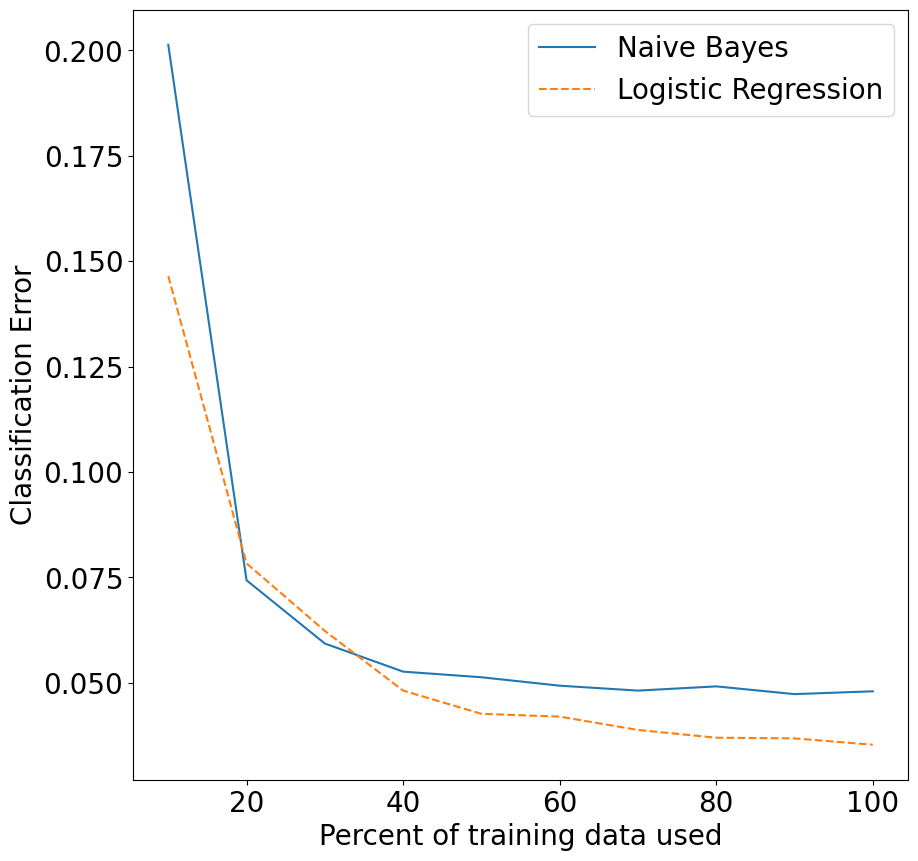

In [13]:
# TODO: insert your code for experiments
###################################################
##### YOUR CODE STARTS HERE #######################
###################################################
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target 

print("Number missing values:",np.isnan(X).sum())
# There are no missing values in the iris dataset
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print('\nData types of each feature:')
print(df.dtypes)
print('\nSummary statistics of each feature:')
print(df.describe())
print('\nFirst five rows of the dataset:')
print(df.head())

nbc = NBC(feature_types=['r', 'r', 'r', 'r'])
lr = LogisticRegression(max_iter=1000)
tst_errs_nbc, tst_errs_lr = compareNBCvsLR(nbc, lr, X, y)
makePlot(tst_errs_nbc, tst_errs_lr)


**Dataset 2: Voting Dataset**

https://archive.ics.uci.edu/ml/datasets/congressional+voting+records

The logistic regression line meets the naive bayes line early in the plot. 

C:\Users\basia\AppData\Local\Temp\ipykernel_13108\1947159453.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  voting = voting.replace({'y': 1, 'n': 0})


   label  handicapped-infants  water-project-cost-sharing  \
0      0                    0                           1   
1      0                    0                           1   
2      1                    0                           1   
3      1                    0                           1   
4      1                    1                           1   

   adoption-of-the-budget-resolution  physician-fee-freeze  el-salvador-aid  \
0                                  0                     1                1   
1                                  0                     1                1   
2                                  1                     0                1   
3                                  1                     0                1   
4                                  1                     0                1   

   religious-groups-in-schools  anti-satellite-test-ban  \
0                            1                        0   
1                            1          

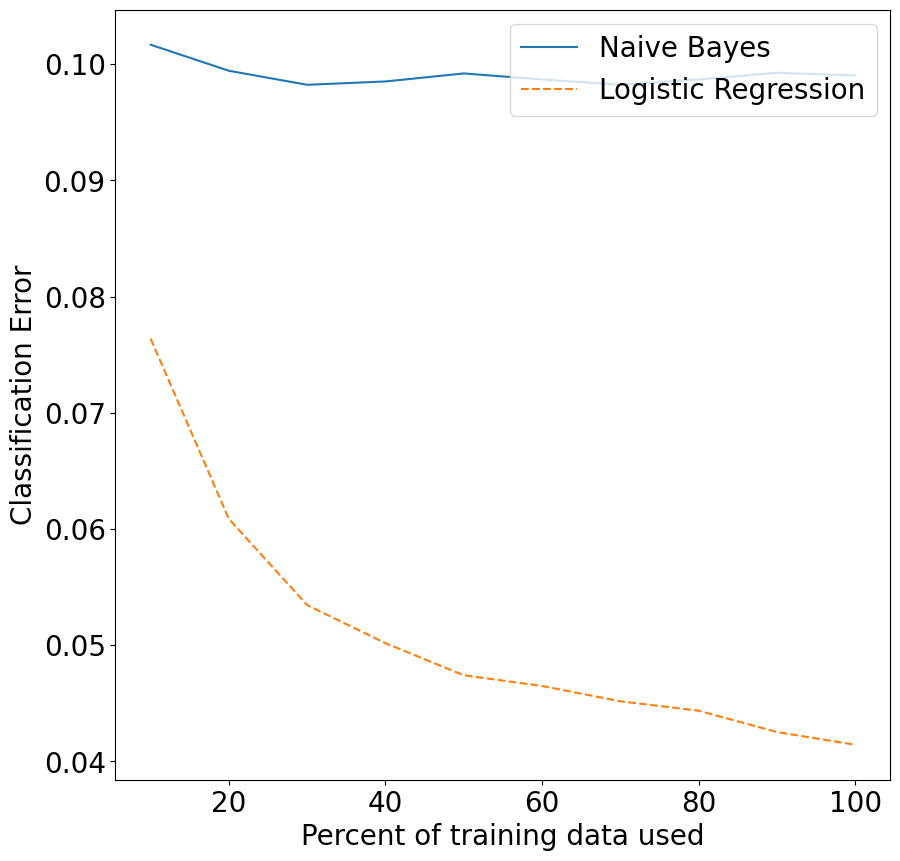

In [14]:
# load the dataset
# TODO: insert your code for experiments
###################################################
##### YOUR CODE STARTS HERE #######################
###################################################
voting = pd.read_csv('./datasets/voting.csv', na_values=[""])

# voting.info()
# print(voting.head())
# print(voting.isna().sum())

# Dropping the feature with too many missing values
voting = voting.drop(columns=['export-administration-act-south-africa'])

#Imputing missing values with mode
for column in voting.columns[1:]: 
    voting[column] = voting[column].fillna(voting[column].mode()[0])
    
voting = voting.replace({'y': 1, 'n': 0})
voting['label'] = voting['label'].map({'republican': 0, 'democrat': 1})

X = voting.drop(columns=['label']).values
y = voting['label'].values

voting_feature_types = ['b'] * X.shape[1]

print(voting.head())
print("Shape:", voting.shape)

nbc = NBC(feature_types=voting_feature_types)
lr = LogisticRegression(max_iter=1000)
tst_errs_nbc, tst_errs_lr = compareNBCvsLR(nbc, lr, X, y)
makePlot(tst_errs_nbc, tst_errs_lr)
# print(voting.dtypes)
###################################################
##### YOUR CODE ENDS HERE #########################
###################################################

**Dataset 3: Breast Cancer Dataset (Bonus Tasks)**

https://archive.ics.uci.edu/ml/datasets/breast+cancer

The dataset has continues, binary and categorical features. It also has missing values.

Hints: You can precompute the size of the domains of the categorical features.

In [15]:
# load the dataset
# TODO: insert your code for experiments
###################################################
##### YOUR CODE STARTS HERE #######################
###################################################
cancer = pd.read_csv('./datasets/breast-cancer.csv', na_values=["?"])

cancer.info()

for column in cancer.columns[0:]: 
    print(cancer[column].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor-size   286 non-null    object
 4   inv-nodes    286 non-null    object
 5   node-caps    278 non-null    object
 6   deg-malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast-quad  285 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB
Class
no-recurrence-events    201
recurrence-events        85
Name: count, dtype: int64
age
50-59    96
40-49    90
60-69    57
30-39    36
70-79     6
20-29     1
Name: count, dtype: int64
menopause
premeno    150
ge40       129
lt40         7
Name: count, dtype: int64
tumor-size
30-34    60
25-29    54
20-24    50
15-19    30
10-14    28
40-44    2

In [16]:
#dropping missing values
cancer = cancer.dropna().reset_index(drop=True)

#Age 
age_order = ['20-29', '30-39', '40-49', '50-59','60-69', '70-79']
cancer['age'] = (cancer['age'].astype('category').cat.set_categories(age_order, ordered=True).cat.codes)

#Menopause
menopause_order = ['lt40', 'ge40', 'premeno']
cancer['menopause'] = (cancer['menopause'].astype('category').cat.set_categories(menopause_order, ordered=True).cat.codes)

#Tumor size
tumor_size_order = ['0-4', '5-9', '10-14', '15-19', '20-24','25-29', '30-34', '35-39', '40-44','45-49', '50-54']
cancer['tumor-size'] = (cancer['tumor-size'].astype('category').cat.set_categories(tumor_size_order, ordered=True).cat.codes)

#Inv-nodes
inv_nodes_order = ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '24-26']
cancer['inv-nodes'] = (cancer['inv-nodes'].astype('category').cat.set_categories(inv_nodes_order, ordered=True).cat.codes)

#Node-caps
cancer['node-caps'] = cancer['node-caps'].map({'no': 0, 'yes': 1})

#Deg-malig - This is not a continous feature
cancer['deg-malig'] = cancer['deg-malig'] - 1

#Breast
cancer['breast'] = cancer['breast'].map({'left': 0, 'right': 1})

#breast-quad
quad_dummies = pd.get_dummies(cancer['breast-quad'], prefix='quad', drop_first=True)
quad_dummies = quad_dummies.astype(int)

#irradiat
cancer['irradiat'] = cancer['irradiat'].map({'no': 0, 'yes': 1})

#Class
cancer['Class'] = cancer['Class'].map({'no-recurrence-events':0, 'recurrence-events':1})

cancer = cancer.drop(columns=['breast-quad'])
cancer = pd.concat([cancer, quad_dummies], axis=1)

In [24]:
X_cancer = cancer.drop(columns=['Class']).values
y_cancer = cancer['Class'].values
cancer_feature_types = ['c','c','c','c','b','c','b','b','b','b','b','b']


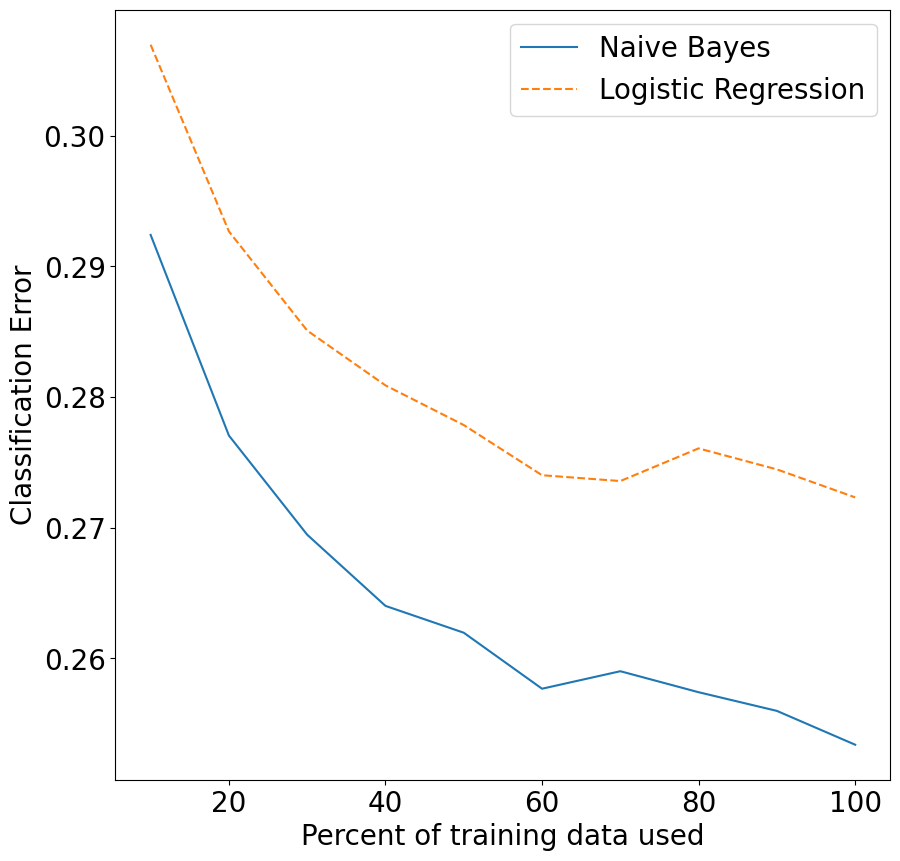

In [25]:
nbc = NBC(feature_types=cancer_feature_types)
lr = LogisticRegression(max_iter=1000)
tst_errs_nbc, tst_errs_lr = compareNBCvsLR(nbc, lr, X_cancer, y_cancer)
makePlot(tst_errs_nbc, tst_errs_lr)